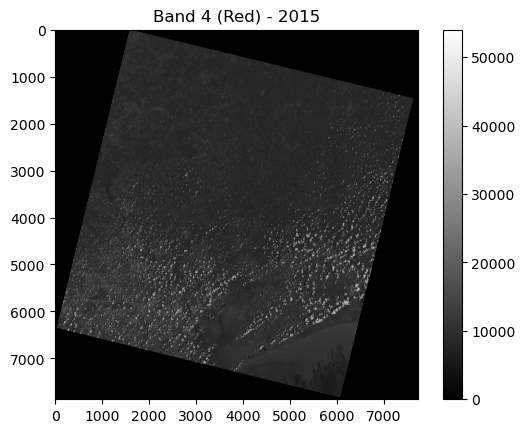

In [1]:
import rasterio
import matplotlib.pyplot as plt

b4_path = "LANDSAT/2015/LC08_L2SP_025039_20150807_20230718_02_T1_SR_B4.TIF"

with rasterio.open(b4_path) as src:
    b4 = src.read(1)
    profile = src.profile

plt.imshow(b4, cmap="gray")
plt.title("Band 4 (Red) - 2015")
plt.colorbar()
plt.show()

C:\Users\kayma\AppData\Local\Temp\ipykernel_2068\3358240827.py:14: RuntimeWarning: invalid value encountered in divide
  (b5 - b4) / (b5 + b4)


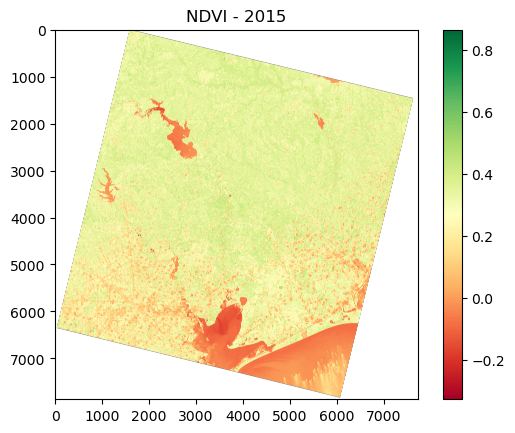

In [2]:
import numpy as np

b5_path = "LANDSAT/2015/LC08_L2SP_025039_20150807_20230718_02_T1_SR_B5.TIF"

with rasterio.open(b5_path) as src:
    b5 = src.read(1)

b4 = b4.astype(float)
b5 = b5.astype(float)

ndvi = np.where(
    (b5 + b4) == 0,
    np.nan,
    (b5 - b4) / (b5 + b4)
)

plt.imshow(ndvi, cmap="RdYlGn")
plt.title("NDVI - 2015")
plt.colorbar()
plt.show()

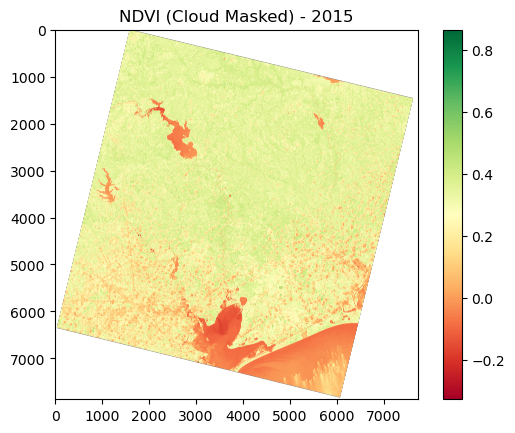

In [3]:
qa_path = "LANDSAT/2015/LC08_L2SP_025039_20150807_20230718_02_T1_QA_PIXEL.TIF"

with rasterio.open(qa_path) as src:
    qa = src.read(1)

cloud_mask = qa > 1

ndvi_clean = np.where(cloud_mask, ndvi, np.nan)

plt.imshow(ndvi_clean, cmap="RdYlGn")
plt.title("NDVI (Cloud Masked) - 2015")
plt.colorbar()
plt.show()

C:\Users\kayma\AppData\Local\Temp\ipykernel_2068\1467578987.py:23: RuntimeWarning: invalid value encountered in divide
  (b5_clip - b4_clip) / (b5_clip + b4_clip)


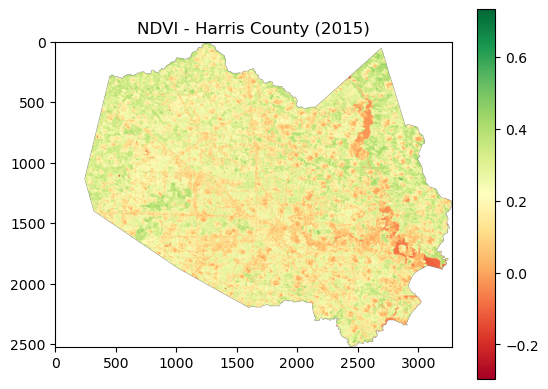

In [4]:
from rasterio.mask import mask
import geopandas as gpd

harris = gpd.read_file("boundaries/harris_county.shp")

with rasterio.open(b4_path) as src:
    raster_crs = src.crs

harris = harris.to_crs(raster_crs)

with rasterio.open(b4_path) as src:
    b4_clip, transform = mask(src, harris.geometry, crop=True)

with rasterio.open(b5_path) as src:
    b5_clip, transform = mask(src, harris.geometry, crop=True)

b4_clip = b4_clip[0].astype(float)
b5_clip = b5_clip[0].astype(float)

ndvi_clip = np.where(
    (b5_clip + b4_clip) == 0,
    np.nan,
    (b5_clip - b4_clip) / (b5_clip + b4_clip)
)

plt.imshow(ndvi_clip, cmap="RdYlGn")
plt.title("NDVI - Harris County (2015)")
plt.colorbar()
plt.show()

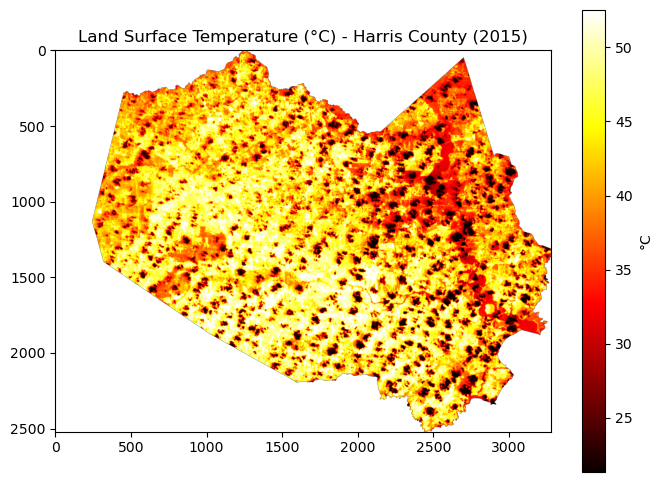

Min: 12.48876752000001
Max: 67.6351022
Mean: 41.05948427713274


In [5]:
st_path = "LANDSAT/2015/LC08_L2SP_025039_20150807_20230718_02_T1_ST_B10.TIF"

with rasterio.open(st_path) as src:
    st_clip, transform = mask(src, harris.geometry, crop=True)

st_clip = st_clip[0].astype(float)

st_clip[st_clip == 0] = np.nan

lst_c = st_clip * 0.00341802 + 149.0 - 273.15

lst_c[(lst_c < 0) | (lst_c > 70)] = np.nan

vmin = np.nanpercentile(lst_c, 2)
vmax = np.nanpercentile(lst_c, 98)

plt.figure(figsize=(8, 6))
plt.imshow(lst_c, cmap="hot", vmin=vmin, vmax=vmax)
plt.title("Land Surface Temperature (°C) - Harris County (2015)")
plt.colorbar(label="°C")
plt.show()

print("Min:", np.nanmin(lst_c))
print("Max:", np.nanmax(lst_c))
print("Mean:", np.nanmean(lst_c))

Baseline temperature: 34.99199812706187


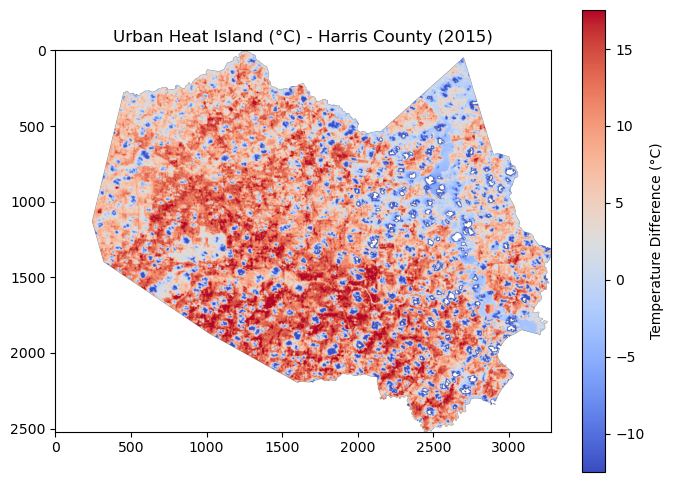

In [6]:

veg_mask = ndvi_clip > 0.5

lst_clean = lst_c.copy()
lst_clean[(lst_clean < 20) | (lst_clean > 60)] = np.nan

baseline_temp = np.nanmean(lst_clean[veg_mask])

print("Baseline temperature:", baseline_temp)

uhi = lst_clean - baseline_temp

vmin = np.nanpercentile(uhi, 2)
vmax = np.nanpercentile(uhi, 98)

plt.figure(figsize=(8,6))
plt.imshow(uhi, cmap="coolwarm", vmin=vmin, vmax=vmax)
plt.title("Urban Heat Island (°C) - Harris County (2015)")
plt.colorbar(label="Temperature Difference (°C)")
plt.show()

In [7]:
np.save("LANDSAT/2015/uhi_2015.npy", uhi)